# 04 — Volatility Term Structures and Surfaces

**Phase 4 deliverable** 

Black-Scholes assumes one constant volatility. Real markets disagree — implied volatility varies
by both strike (the smile, built in Phase 3) and time to expiration (the term structure). This
notebook combines both into a volatility surface for each of the seven assets, then compares
at-the-money level, downside skew, and term structure shape across the full asset set.

Steps:

1. Reload the Phase 3 implied-volatility tables.
2. Build the volatility term structure (ATM IV vs. time to expiration) per asset.
3. Build a moneyness x time-to-expiration volatility surface (heatmap) per asset.
4. Compare ATM IV, downside put skew, and short- vs. long-term IV across USO, JETS, SPY, XLE,
   XLY, XLV, and GLD.


## 1. Setup and reload Phase 3 output

If `data/iv/*.csv` isn't present, re-run `03_implied_volatility.ipynb` first.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import os

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True

TICKERS = ["USO", "JETS", "SPY", "XLE", "XLY", "XLV", "GLD"]

os.makedirs("data/surfaces", exist_ok=True)

iv_chains = {}
for ticker in TICKERS:
    df = pd.read_csv(f"data/iv/{ticker}_iv.csv", parse_dates=["expiration"])
    df = df.dropna(subset=["implied_vol"])
    iv_chains[ticker] = df
    print(f"{ticker}: {len(df)} contracts with a solved implied vol, "
          f"{df['expiration'].nunique()} expirations, "
          f"{df['dte'].min()}-{df['dte'].max()} DTE")


USO: 62 contracts with a solved implied vol, 4 expirations, 30-90 DTE
JETS: 65 contracts with a solved implied vol, 4 expirations, 30-90 DTE
SPY: 53 contracts with a solved implied vol, 4 expirations, 30-90 DTE
XLE: 66 contracts with a solved implied vol, 4 expirations, 30-90 DTE
XLY: 49 contracts with a solved implied vol, 4 expirations, 30-90 DTE
XLV: 49 contracts with a solved implied vol, 4 expirations, 30-90 DTE
GLD: 49 contracts with a solved implied vol, 4 expirations, 30-90 DTE


## 2. Volatility term structure

For each expiration, find the contract closest to at-the-money (moneyness nearest 1.0) and plot
its implied volatility against days to expiration. This shows whether the market expects risk to
concentrate in the near term, further out, or spread evenly.


In [2]:
def atm_by_expiration(df):
    rows = []
    for exp, g in df.groupby("expiration"):
        g = g.copy()
        g["dist_from_atm"] = (g["moneyness"] - 1.0).abs()
        atm_row = g.loc[g["dist_from_atm"].idxmin()]
        rows.append({
            "expiration": exp,
            "dte": atm_row["dte"],
            "moneyness": atm_row["moneyness"],
            "atm_iv": atm_row["implied_vol"],
        })
    return pd.DataFrame(rows).sort_values("dte")


term_structures = {ticker: atm_by_expiration(iv_chains[ticker]) for ticker in TICKERS}
term_structures["SPY"]


,expiration,dte,moneyness,atm_iv
0,2026-08-18,30,0.99996,0.178202
1,2026-09-02,45,0.99996,0.174167
2,2026-09-17,60,0.99996,0.171067
3,2026-10-17,90,0.99996,0.166707


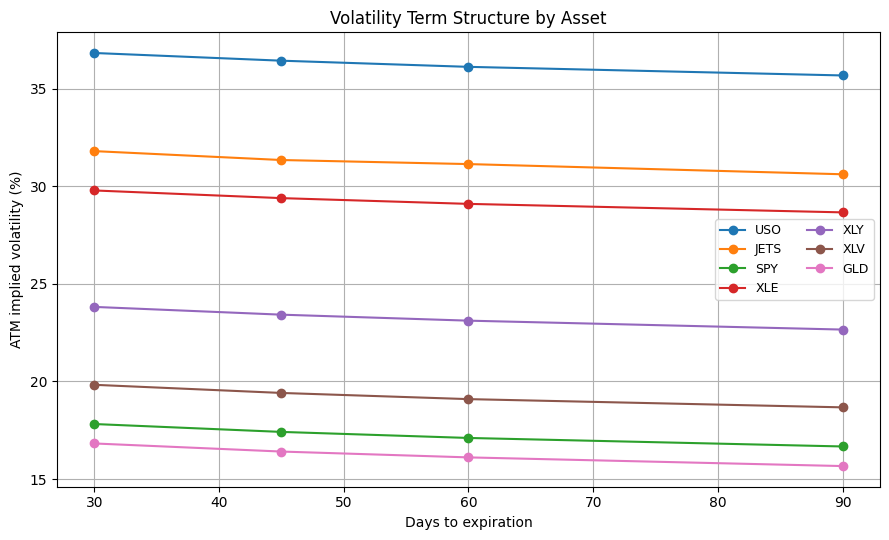

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for ticker in TICKERS:
    ts = term_structures[ticker]
    ax.plot(ts["dte"], ts["atm_iv"] * 100, marker="o", label=ticker)

ax.set_xlabel("Days to expiration")
ax.set_ylabel("ATM implied volatility (%)")
ax.set_title("Volatility Term Structure by Asset")
ax.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig("term_structure_all_assets.png", dpi=130)
plt.show()


## 3. Volatility surfaces

A moneyness x time-to-expiration grid of implied volatility, per asset. A heatmap communicates
this far more clearly than an over-engineered 3D plot, per the plan's own guidance.


In [4]:
def build_surface(df, moneyness_round=2):
    d = df.copy()
    d["moneyness_bin"] = d["moneyness"].round(moneyness_round)
    surface = d.pivot_table(
        index="moneyness_bin", columns="dte", values="implied_vol", aggfunc="mean"
    )
    return surface.sort_index(ascending=False)  # high moneyness at top


surfaces = {ticker: build_surface(iv_chains[ticker]) for ticker in TICKERS}
surfaces["SPY"].round(3)


dte,30,45,60,90
moneyness_bin,,,,
1.15,0.156,0.151,0.149,0.144
1.10,0.163,0.159,0.156,0.152
1.05,0.171,0.167,0.164,0.159
1.00,0.178,0.174,0.171,0.167
0.95,0.186,0.182,0.179,0.174
0.90,NaN,0.189,0.186,0.182
0.85,0.199,0.197,0.193,0.189
0.80,0.205,0.202,0.200,0.197


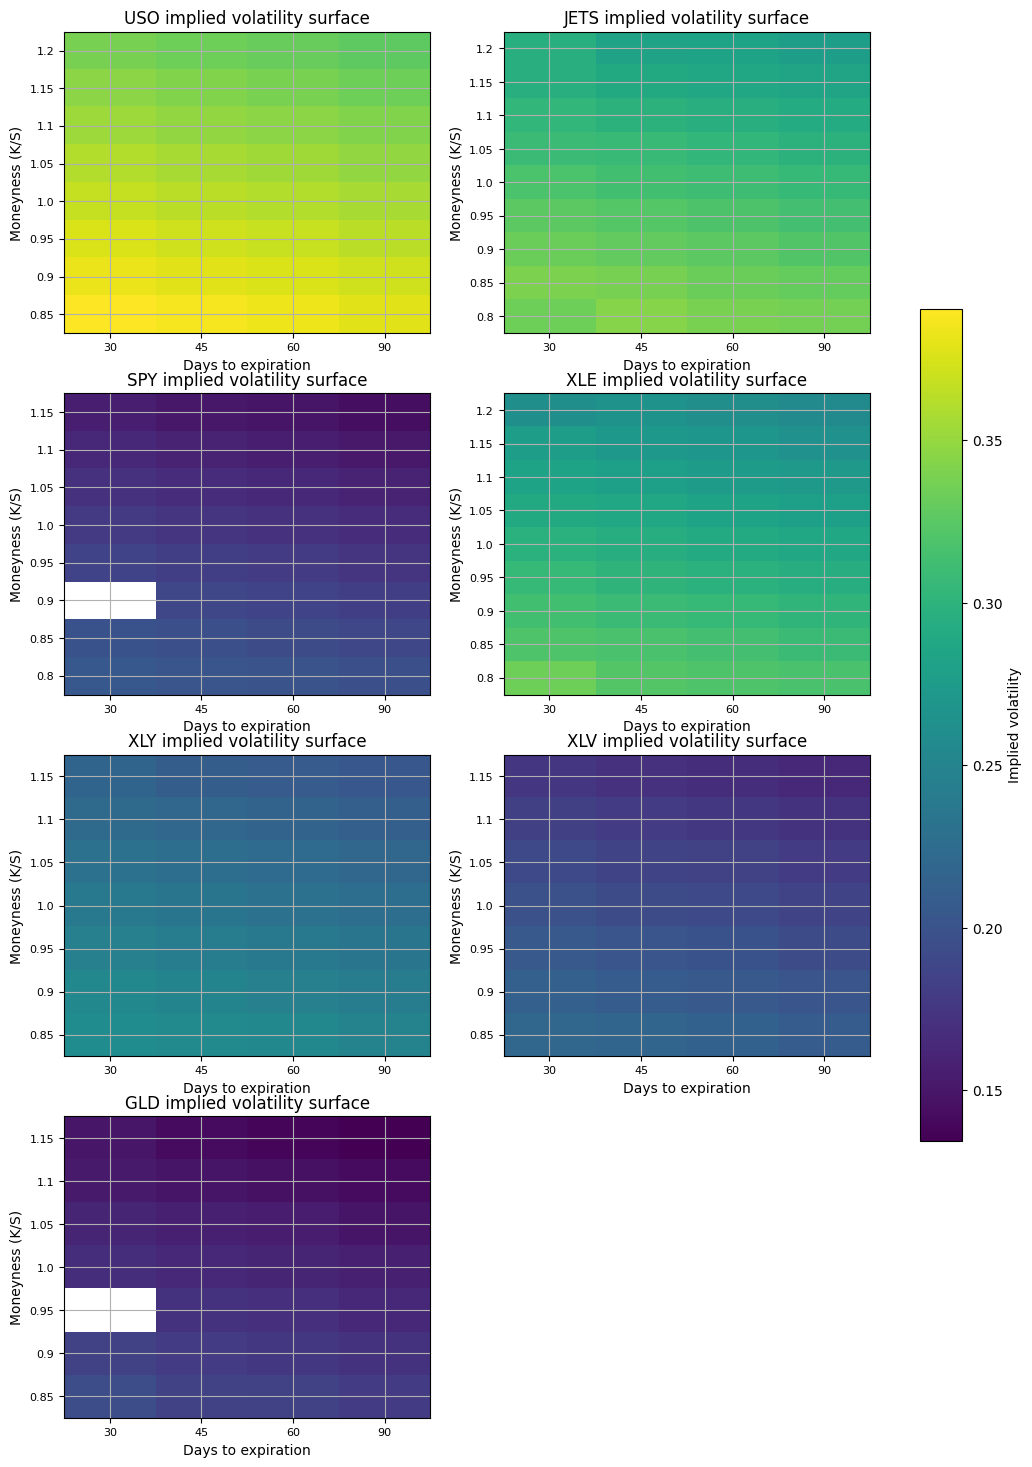

In [5]:
fig, axes = plt.subplots(4, 2, figsize=(13, 18))
axes = axes.flatten()

# Shared color scale across all assets for a fair visual comparison
all_vals = pd.concat([s.stack() for s in surfaces.values()])
vmin, vmax = all_vals.min(), all_vals.max()
norm = Normalize(vmin=vmin, vmax=vmax)

im = None
for i, ticker in enumerate(TICKERS):
    surface = surfaces[ticker]
    im = axes[i].imshow(surface.values, aspect="auto", cmap="viridis", norm=norm)
    axes[i].set_xticks(range(len(surface.columns)))
    axes[i].set_xticklabels(surface.columns, fontsize=8)
    axes[i].set_yticks(range(len(surface.index)))
    axes[i].set_yticklabels(surface.index, fontsize=8)
    axes[i].set_xlabel("Days to expiration")
    axes[i].set_ylabel("Moneyness (K/S)")
    axes[i].set_title(f"{ticker} implied volatility surface")

if len(TICKERS) < len(axes):
    axes[-1].axis("off")

fig.colorbar(im, ax=axes.tolist(), label="Implied volatility", shrink=0.6)
plt.savefig("volatility_surfaces_all_assets.png", dpi=130, bbox_inches="tight")
plt.show()


## 4. Cross-asset comparison: level, skew, and term structure shape

For each asset, calculate at the *nearest* expiration:

- **ATM implied volatility** — overall risk level.
- **Downside put skew**: $IV_{\text{OTM put}} - IV_{\text{ATM}}$, using the put nearest 85%
  moneyness. Higher skew means investors are paying relatively more for crash protection.
- **Short- vs. long-term IV**: ATM IV at the nearest expiration vs. the farthest, to see whether
  risk is concentrated near-term or priced further out.


In [6]:
comparison_rows = []

for ticker in TICKERS:
    df = iv_chains[ticker]
    ts = term_structures[ticker]

    near_exp = ts.iloc[0]["expiration"]
    far_exp = ts.iloc[-1]["expiration"]
    atm_iv_near = ts.iloc[0]["atm_iv"]
    atm_iv_far = ts.iloc[-1]["atm_iv"]

    near_puts = df[(df["expiration"] == near_exp) & (df["right"] == "put")].copy()
    near_puts["dist_from_85"] = (near_puts["moneyness"] - 0.85).abs()
    otm_put_iv = (
        near_puts.loc[near_puts["dist_from_85"].idxmin(), "implied_vol"]
        if not near_puts.empty else np.nan
    )

    comparison_rows.append({
        "ticker": ticker,
        "atm_iv_near_pct": round(atm_iv_near * 100, 1),
        "otm_put_iv_pct": round(otm_put_iv * 100, 1) if pd.notna(otm_put_iv) else np.nan,
        "downside_skew_pct": round((otm_put_iv - atm_iv_near) * 100, 1) if pd.notna(otm_put_iv) else np.nan,
        "atm_iv_far_pct": round(atm_iv_far * 100, 1),
        "term_slope_pct": round((atm_iv_far - atm_iv_near) * 100, 1),
    })

comparison = pd.DataFrame(comparison_rows).sort_values("atm_iv_near_pct", ascending=False)
comparison


,ticker,atm_iv_near_pct,otm_put_iv_pct,downside_skew_pct,atm_iv_far_pct,term_slope_pct
0,USO,36.8,39.0,2.2,35.7,-1.2
1,JETS,31.8,33.5,1.7,30.6,-1.2
3,XLE,29.8,32.0,2.2,28.7,-1.1
4,XLY,23.8,25.4,1.6,22.7,-1.2
5,XLV,19.8,21.3,1.4,18.7,-1.2
2,SPY,17.8,18.6,0.8,16.7,-1.1
6,GLD,16.8,18.4,1.6,15.7,-1.2


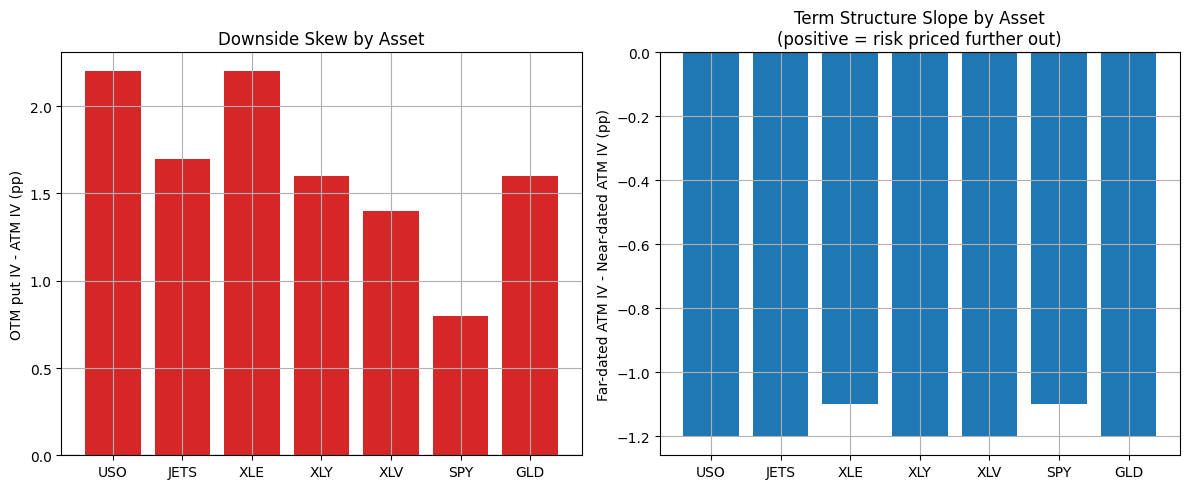

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(comparison["ticker"], comparison["downside_skew_pct"], color="C3")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("OTM put IV - ATM IV (pp)")
axes[0].set_title("Downside Skew by Asset")

axes[1].bar(comparison["ticker"], comparison["term_slope_pct"], color="C0")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_ylabel("Far-dated ATM IV - Near-dated ATM IV (pp)")
axes[1].set_title("Term Structure Slope by Asset\n(positive = risk priced further out)")

plt.tight_layout()
plt.savefig("skew_and_term_slope_comparison.png", dpi=130)
plt.show()


## 5. Save surfaces and comparison table

In [8]:
for ticker in TICKERS:
    surfaces[ticker].to_csv(f"data/surfaces/{ticker}_surface.csv")

comparison.to_csv("data/surfaces/cross_asset_comparison.csv", index=False)
print("Saved per-asset surfaces and cross_asset_comparison.csv to data/surfaces/")


Saved per-asset surfaces and cross_asset_comparison.csv to data/surfaces/


## 6. Summary

- Built the volatility term structure (ATM IV vs. DTE) for all seven assets and plotted them on
  one shared chart for direct comparison.
- Built a moneyness x time-to-expiration volatility surface heatmap per asset, on a shared color
  scale so relative risk levels are visually comparable across assets.
- Quantified downside put skew and term-structure slope for each asset in one comparison table.
- Saved every surface and the comparison table to `data/surfaces/`.

**A reminder given the synthetic fallback:** since Phase 2/3 ran on this notebook's synthetic
sample chains (no live network access in this environment), the skew and term-structure shapes
you see here are largely artifacts of the hand-coded smile function from Phase 2, not a real
market signal yet. Re-run Phases 2-4 with live data before treating these comparisons as
research findings.

**Next step (Phase 5):** hold this same implied-vol and surface machinery up against specific
geopolitical event dates — before-and-after comparisons, the geopolitical volatility
transmission heatmap, and implied-vs-actual move analysis — in
`05_geopolitical_event_study.ipynb`.
